# TP2 - Aproximación de imágenes con algoritmos genéticos

Este notebook contiene únicamente el **experimento**. El motor está separado en scripts:

- `tp2_ga/engine.py`: población y bucle evolutivo.
- `tp2_ga/operators.py`: selección, cruza, mutación y supervivencia.
- `tp2_ga/fitness.py`: función de aptitud y evaluación CPU/CUDA.
- `tp2_ga/render.py`: rasterizado de triángulos.
- `tp2_ga/io.py`: carga y exportación.

Ejecutar las celdas en orden. La población inicial es completamente aleatoria.

## 1. Imports y rutas

In [10]:
from dataclasses import asdict, replace
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path.cwd()
TP2_DIR = PROJECT_DIR / 'TP2' if (PROJECT_DIR / 'TP2').is_dir() else PROJECT_DIR
if str(TP2_DIR) not in sys.path:
    sys.path.insert(0, str(TP2_DIR))

from tp2_ga import (
    GAConfig, GeneticImageGA, export_triangles, load_target_image,
    render_high_resolution, render_triangles,
)

## 2. Imagen de entrada

El ejercicio recibe una imagen y la cantidad de triángulos. Se elige una sola imagen explícitamente.

prueba.jpeg: (1024, 1024) -> (120, 120)


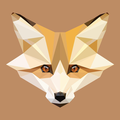

In [11]:
IMAGE_NAME = 'prueba.jpeg'
TARGET_MAX_SIDE = 120
TRIANGLE_COUNT = 600

IMAGE_PATH = TP2_DIR / 'imagenesprueba' / IMAGE_NAME
original_image, target = load_target_image(IMAGE_PATH, TARGET_MAX_SIDE)
print(f'{IMAGE_PATH.name}: {original_image.size} -> {target.size}')
display(target)

## 3. Representación y fitness

Un individuo contiene `K` triángulos. Cada triángulo posee 10 genes normalizados:

`(x1, y1, x2, y2, x3, y3, r, g, b, a)`

Esta representación mantiene juntas la geometría y el color de cada figura. Las cruzas operan sobre bloques completos de 10 genes para no producir triángulos parcialmente cortados.

El fitness es un error a minimizar compuesto por:

- MSE: similitud global de color.
- Sobel: preservación de bordes y siluetas.
- SSIM: semejanza estructural local.

La población inicial no consulta la imagen objetivo: todos sus genes se generan con una distribución uniforme en `[0, 1]`.

## 4. Hiperparámetros

In [12]:
config = GAConfig(
    population_size=64,
    generations=15_000,
    mutation_probability=0.75,
    crossover_probability=0.55,
    elite_size=3,
    random_injection=2,
    stop_error=0.02,
    patience=800,
    evaluation_size=120,
    initial_evaluation_size=48,  # 48 -> 84 -> 120; llega a 120 al 65 %
    seed=42,
    target_guided_initialization=False,  # Gen 0 uniforme; depende únicamente de seed
    use_gpu=True,
    selection='tournament_probabilistic',
    tournament_size=4,
    crossover='region',           # one_point, two_point, uniform o region
    mutation='triangle',          # gene, multigene, non_uniform o triangle
    survival='exclusive',         # additive o exclusive
    ranking_pressure=1.5,
    color_weight=0.55,
    edge_weight=0.30,
    ssim_weight=0.15,
    detail_boost=4.0,
    pyramid_scales=(0.5, 1.0),
    pyramid_weights=(0.25, 0.75),
)
config

GAConfig(population_size=64, generations=15000, mutation_probability=0.75, crossover_probability=0.55, elite_size=3, random_injection=2, stop_error=0.02, patience=800, evaluation_size=120, initial_evaluation_size=48, seed=42, use_gpu=True, selection='tournament_probabilistic', crossover='region', mutation='triangle', survival='exclusive', tournament_size=4, tournament_probability=0.8, ranking_pressure=1.5, boltzmann_temperature=1.0, boltzmann_min_temperature=0.1, color_weight=0.55, edge_weight=0.3, ssim_weight=0.15, detail_boost=4.0, pyramid_scales=(0.5, 1.0), pyramid_weights=(0.25, 0.75), resolution_change_fractions=(0.35, 0.65), target_guided_initialization=False, progress=True)

## 5. Ejecutar el algoritmo genético

La barra informa avance, ETA, resolución y mejor error. La primera ejecución CUDA incluye la compilación del kernel.

In [13]:
ga = GeneticImageGA(target, TRIANGLE_COUNT, config)
print(f'Backend: {ga.evaluator.backend}')
result = ga.run()

print(f'Generaciones: {result.generations_completed}')
print(f'Motivo de parada: {result.stop_reason}')
print(f'Error final: {result.best_fitness:.6f}')
print(f'Tiempo: {result.elapsed_seconds:.1f} s')

Backend: CUDA (NVIDIA GeForce RTX 5090)


Evolución AG:   0%|          | 0/15000 [00:00<?, ?gen/s, error=0.286120, res=48, sin_mejora=0]

Evolución AG:  35%|███▌      | 5274/15000 [00:36<01:09, 139.47gen/s, error=0.094486, res=84, sin_mejora=2]

Evaluación aumentada a lado 84


Evolución AG:  65%|██████▌   | 9772/15000 [01:08<00:36, 143.71gen/s, error=0.072217, res=120, sin_mejora=1]

Evaluación aumentada a lado 120


Evolución AG: 100%|██████████| 15000/15000 [01:45<00:00, 142.80gen/s, error=0.047478, res=120, sin_mejora=6]


Generaciones: 15000
Motivo de parada: maximum_generations
Error final: 0.054334
Tiempo: 105.7 s


## 6. Convergencia y diversidad

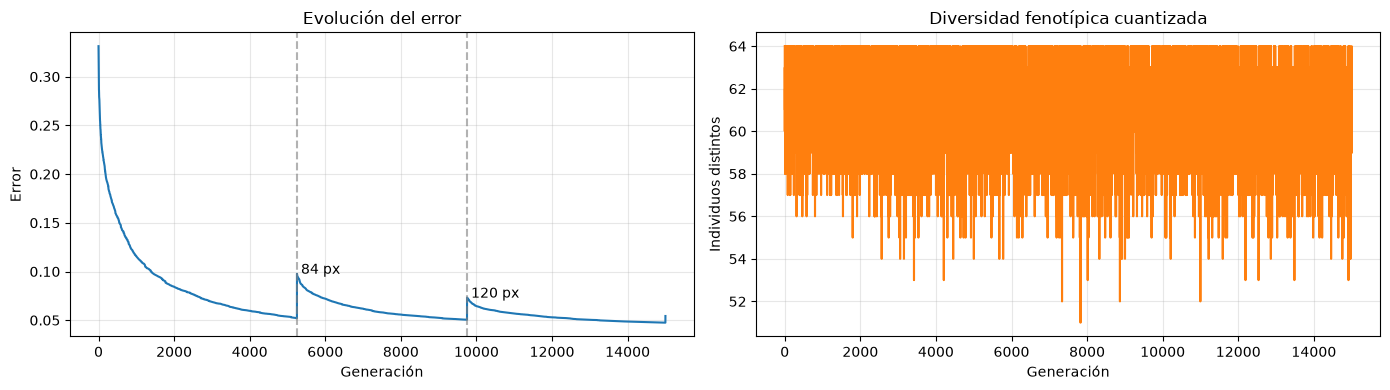

In [14]:
generations = np.arange(len(result.history))
resolution_changes = np.flatnonzero(np.diff(result.resolution_history)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(generations, result.history)
for change in resolution_changes:
    axes[0].axvline(change, color='gray', linestyle='--', alpha=0.6)
    axes[0].text(change, result.history[change], f' {result.resolution_history[change]} px')
axes[0].set(title='Evolución del error', xlabel='Generación', ylabel='Error')
axes[0].grid(True, alpha=0.3)

axes[1].plot(generations, result.diversity_history, color='tab:orange')
axes[1].set(title='Diversidad fenotípica cuantizada', xlabel='Generación', ylabel='Individuos distintos')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Resultado final

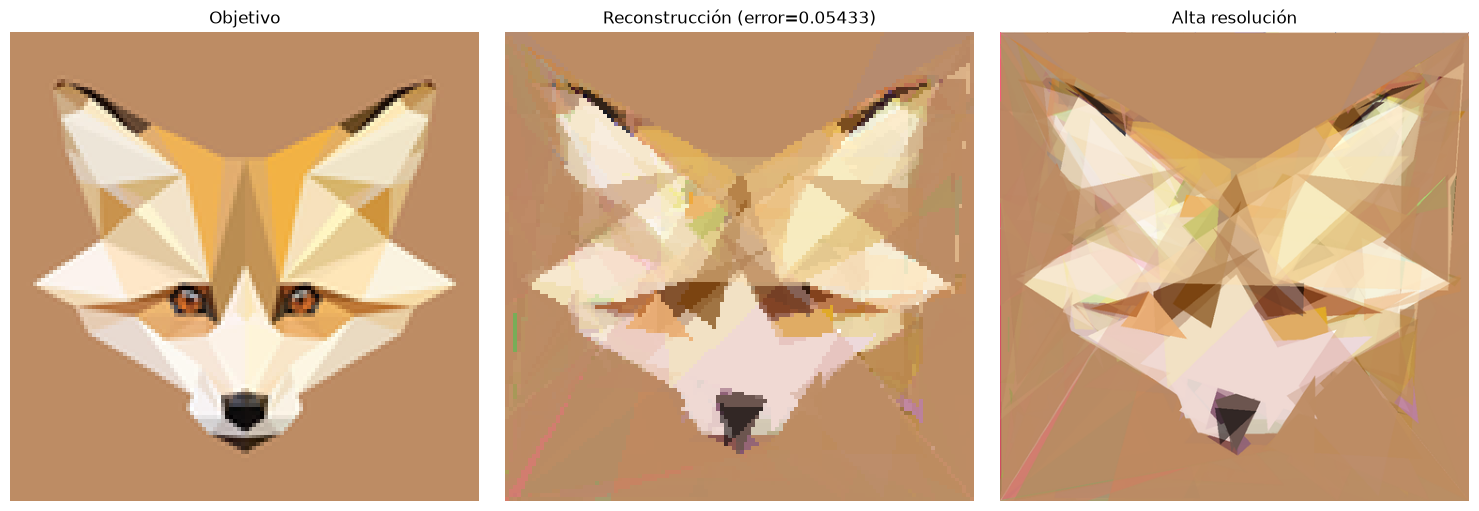

In [15]:
best_triangles = ga.genes_to_triangles(result.best_genes)
evaluation_render = render_triangles(best_triangles, target.size)

max_output_side = 500
scale = min(1.0, max_output_side / max(original_image.size))
output_size = tuple(max(1, round(dimension * scale)) for dimension in original_image.size)
final_render = render_high_resolution(best_triangles, output_size, supersample=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(
    axes,
    [target, evaluation_render, final_render],
    ['Objetivo', f'Reconstrucción (error={result.best_fitness:.5f})', 'Alta resolución'],
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 8. Evolución visual

Se muestran cinco hitos representativos: la población inicial, 25 %, 50 %, 75 % y el resultado final. Si la ejecución se detiene anticipadamente, el último panel corresponde a la generación realmente alcanzada.

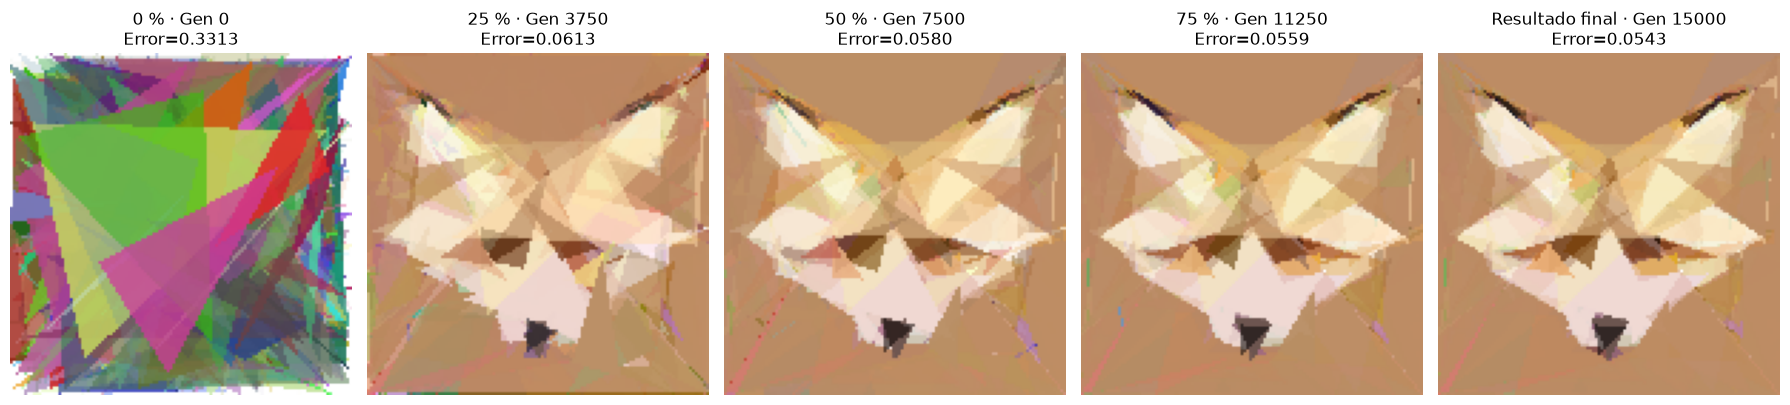

In [16]:
target_generations = [
    0,
    round(config.generations * 0.25),
    round(config.generations * 0.50),
    round(config.generations * 0.75),
    result.generations_completed,
]

# También funciona con corridas anteriores que guardaban snapshots periódicos.
shown = [
    min(result.snapshots, key=lambda snapshot: abs(max(snapshot[0], 0) - target))
    for target in target_generations
]
labels = ['0 %', '25 %', '50 %', '75 %', 'Resultado final']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for axis, label, (generation, error, genes) in zip(axes, labels, shown):
    image = render_triangles(ga.genes_to_triangles(genes), target.size)
    axis.imshow(image)
    shown_generation = max(generation, 0)
    axis.set_title(f'{label} · Gen {shown_generation}\nError={error:.4f}')
    axis.axis('off')
plt.tight_layout()
plt.show()

## 9. Exportar entregables

Se guardan la imagen, los `K` triángulos completos y las métricas de la corrida.

In [17]:
OUTPUT_DIR = TP2_DIR / 'resultados_mejorados'
OUTPUT_DIR.mkdir(exist_ok=True)

image_output = OUTPUT_DIR / 'reconstruccion_final.png'
triangles_output = export_triangles(best_triangles, OUTPUT_DIR / 'triangulos_finales.json')
metrics_output = OUTPUT_DIR / 'metricas.json'

final_render.save(image_output)
fitness_components = ga.evaluator.evaluate_components(
    result.best_genes, config.evaluation_size
)
metrics = {
    'image': IMAGE_NAME,
    'triangle_count': TRIANGLE_COUNT,
    'best_fitness': result.best_fitness,
    'fitness_components': asdict(fitness_components),
    'generations_completed': result.generations_completed,
    'elapsed_seconds': result.elapsed_seconds,
    'stop_reason': result.stop_reason,
    'backend': result.backend,
    'config': asdict(config),
}
metrics_output.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print(image_output.resolve())
print(triangles_output.resolve())
print(metrics_output.resolve())

/gehme-gpu3/personal/sanchez/DIAO2A/TP2/resultados_mejorados/reconstruccion_final.png
/gehme-gpu3/personal/sanchez/DIAO2A/TP2/resultados_mejorados/triangulos_finales.json
/gehme-gpu3/personal/sanchez/DIAO2A/TP2/resultados_mejorados/metricas.json


## 10. Comparación controlada de operadores (opcional)

Para defender la implementación conviene cambiar un operador por vez y usar la misma semilla. Esta celda queda desactivada porque ejecutar varias corridas completas es costoso.

In [18]:
RUN_COMPARISON = False

if RUN_COMPARISON:
    rows = []
    for selection_method in ['ranking', 'tournament_deterministic', 'roulette']:
        comparison_config = replace(
            config,
            selection=selection_method,
            generations=500,
            initial_evaluation_size=32,
            progress=False,
        )
        comparison = GeneticImageGA(target, TRIANGLE_COUNT, comparison_config).run()
        rows.append({
            'selection': selection_method,
            'error': comparison.best_fitness,
            'generations': comparison.generations_completed,
            'seconds': comparison.elapsed_seconds,
        })
    rows

## Decisiones para la defensa

- **Selección:** ranking evita que diferencias extremas de fitness dominen toda la población.
- **Cruza uniforme:** mezcla triángulos completos y conserva genes geométricos coherentes. También se implementan cruza de uno y dos puntos.
- **Mutación no uniforme:** explora con cambios grandes al principio y ajusta detalles al final. También se implementan Gen y MultiGen.
- **Supervivencia exclusiva:** fuerza el recambio generacional, conservando únicamente la élite. También se implementa supervivencia aditiva.
- **Terminación:** máximo de generaciones, error objetivo o estancamiento.
- **Resolución progresiva:** reduce el costo inicial y reserva la evaluación fina para la etapa final.
- **CUDA:** acelera rasterizado y fitness, pero no delega la implementación del AG a una librería externa.